In [146]:
import torch
import math
import torch.nn as nn
import torch.optim as optim
import copy
import numpy as np
import matplotlib.pyplot as plt

In [147]:
# Set seeds for reproducibility
# torch.manual_seed(42)
# np.random.seed(42)

In [148]:
class Net(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.depth = len(layers) - 1
        self.activation = nn.Tanh()

        # Build the network
        layer_list = []
        for i in range(self.depth - 1):
            layer_list.append(nn.Linear(layers[i], layers[i+1]))
            layer_list.append(self.activation)
        layer_list.append(nn.Linear(layers[-2], layers[-1]))

        self.net = nn.Sequential(*layer_list)

    def forward(self, x, y):
        # Stack inputs: (N, 2)
        X = torch.cat([x, y], dim=1) # Network sees x,y
        return self.net(X)

Domain: A simple unit square.

$D = \{(x, y) \in \mathbb{R}^2 \mid 0 < x < 2, 0 < y < \pi\}$

The PDE: Homogeneous (equals zero).

$$\Delta u = 0 \quad \text{in } D$$

Dirichlet Boundary Conditions: Three sides are zero, but the bottom edge is a sine wave.

$$\begin{cases}
    u(x, 0) = 0 \\
    u(x, \pi) = 0 \\
    u(0, y) = \sin(y) \\
    u(2, y) = e^2 \sin(y)
\end{cases}$$

With the following solution:
$$u(x, y) = e^x \sin(y)$$

In [149]:
# --- Configuration ---
# Compact network as suggested in the paper
layers = [2, 30, 60, 120, 60, 30, 1]
model = Net(layers)

# --- Data Generation (Collocation Points) ---
N_f = 2000  # Interior points
N_b = 400   # Boundary points

x_f = torch.rand(N_f, 1, dtype=torch.float32) * 2.0
x_f.requires_grad_()
y_f = torch.rand(N_f, 1, dtype=torch.float32) * math.pi
y_f.requires_grad_()

u_exact = (torch.exp(x_f)*torch.sin(y_f)).detach()

# Boundary points x:
x_bc_x = torch.cat([torch.zeros(N_b//2, 1), torch.full((N_b//2, 1), 2.0)], dim=0)
y_bc_x = torch.rand(N_b,1)
u_bc_x = torch.cat([torch.sin((y_bc_x[:N_b//2])).detach(), (torch.exp(x_bc_x[N_b//2:]) * torch.sin(y_bc_x[N_b//2:]))], dim=0)

# Boundary points y:
x_bc_y = torch.rand(N_b,1) * 2
y_bc_y = torch.cat([torch.zeros(N_b//2, 1), torch.full((N_b//2, 1), math.pi)], dim=0)

l2_error = {'adam':[], 'std':[], 'sqrt':[], 'log':[]}
l2_relative_errors = {'adam':[], 'std':[], 'sqrt':[], 'log':[]}
mse_errors = {'adam':[], 'std':[], 'sqrt':[], 'log':[]}

In [150]:
def compute_loss(net):

    # PDE residual
    u_f = net(x_f, y_f)
    u_x = torch.autograd.grad(u_f.sum(), x_f, create_graph=True)[0]
    u_y = torch.autograd.grad(u_f.sum(), y_f ,create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y_f, torch.ones_like(u_y), create_graph=True)[0]
    f_res = u_xx + u_yy
    loss_pde = torch.mean(f_res**2)

    # Boundary loss x:
    u_bc_x_pred = net(x_bc_x, y_bc_x)
    loss_bc_x = torch.mean((u_bc_x_pred - u_bc_x)** 2)

    # Boundary loss y:
    u_bc_y_pred = net(x_bc_y, y_bc_y)
    loss_bc_y = torch.mean(u_bc_y_pred** 2)

    return loss_pde + loss_bc_x + loss_bc_y

def record_metrics(net, name):
    # Disable gradients just for metric calculation to save memory/time
    with torch.no_grad():
        u_f = net(x_f, y_f)
        diff = u_f - u_exact

        l2_error[name].append(torch.norm(diff).item())
        l2_relative_errors[name].append((torch.norm(diff) / torch.norm(u_exact)).item())
        mse_errors[name].append(torch.mean(diff ** 2).item())

        plateau_l2 = plateau_l2r = plateau_mse = False
        if len(l2_error[name]) > 100:
            plateau_l2 = all([l2_error[name][-i] == l2_error[name][-i-1] for i in range(1, 100)])
            plateau_l2r = all([l2_relative_errors[name][-i] == l2_relative_errors[name][-i-1] for i in range(1, 100)])
            plateau_mse = all([mse_errors[name][-i] == mse_errors[name][-i-1] for i in range(1, 100)])

        return plateau_l2 and plateau_l2r and plateau_mse

In [151]:
# --- Stage 1: Adam Optimizer (Initialization) ---
print("Stage 1: Pre-training with Adam...")
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1001): # Adam iterations
    optimizer_adam.zero_grad()
    loss = compute_loss(model)
    loss.backward()
    optimizer_adam.step()

    # Record metrics exactly once per epoch
    plateau = record_metrics(model, 'adam')
    if plateau:
        break

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6e}")

Stage 1: Pre-training with Adam...
Epoch 0, Loss: 6.823956e+00
Epoch 100, Loss: 1.704206e+00
Epoch 200, Loss: 6.833623e-02
Epoch 300, Loss: 1.807196e-02
Epoch 400, Loss: 1.006991e-02
Epoch 500, Loss: 6.605275e-03
Epoch 600, Loss: 4.943119e-03
Epoch 700, Loss: 3.537217e-03
Epoch 800, Loss: 6.155008e-03
Epoch 900, Loss: 2.193605e-03
Epoch 1000, Loss: 4.769212e-03


In [152]:
model_std_lbfgs = copy.deepcopy(model) # Experiment 2
model_sqrt_lbfgs = copy.deepcopy(model) # Experiment 3
model_log_lbfgs = copy.deepcopy(model) # Experiment 4
lbfgs_epochs = 2001

In [153]:
# --- EXPERIMENT 1: Continue with Adam (No LBFGS) ---
print("Exp 1: Continuing Adam...")
# opt_1 = optim.Adam(model_no_lbfgs.parameters(), lr=1e-3)
for epoch in range(lbfgs_epochs):
    optimizer_adam.zero_grad()
    loss = compute_loss(model)
    loss.backward()
    optimizer_adam.step()

    # Record metrics exactly once per epoch
    plateau = record_metrics(model, 'adam')
    if plateau:
        break

    if epoch % 100 == 0:
        print(f"Epoch {epoch},  Loss: {loss.item():.6e}")

Exp 1: Continuing Adam...
Epoch 0,  Loss: 1.227339e-02
Epoch 100,  Loss: 1.529577e-03
Epoch 200,  Loss: 1.372934e-03
Epoch 300,  Loss: 3.641553e-03
Epoch 400,  Loss: 3.681842e-03
Epoch 500,  Loss: 2.684260e-03
Epoch 600,  Loss: 1.039690e-03
Epoch 700,  Loss: 1.291905e-03
Epoch 800,  Loss: 8.101222e-03
Epoch 900,  Loss: 1.223146e-03
Epoch 1000,  Loss: 5.158122e-03
Epoch 1100,  Loss: 1.448542e-03
Epoch 1200,  Loss: 8.470658e-04
Epoch 1300,  Loss: 1.843080e-03
Epoch 1400,  Loss: 4.491257e-04
Epoch 1500,  Loss: 7.643015e-03
Epoch 1600,  Loss: 1.303920e-02
Epoch 1700,  Loss: 3.917023e-04
Epoch 1800,  Loss: 1.566094e-03
Epoch 1900,  Loss: 4.727681e-03
Epoch 2000,  Loss: 1.319170e-03


In [154]:
# --- EXPERIMENT 2: Standard LBFGS (Minimize MSE) ---
print("Exp 2: Standard LBFGS (MSE)...")
opt_std = optim.LBFGS(
    model_std_lbfgs.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)


for epoch in range(lbfgs_epochs):
    def closure_std():
        opt_std.zero_grad()
        loss = compute_loss(model_std_lbfgs) # Standard Loss
        loss.backward()
        return loss

    # Take ONE step (the line search happens silently inside here)
    opt_std.step(closure_std)

    # Record metrics exactly once per successful step
    plateau = record_metrics(model_std_lbfgs, 'std')
    if plateau:
        break

    if epoch % 100 == 0:
        current_loss = closure_std().item()
        print(f"L-BFGS Epoch {epoch}, Loss: {current_loss:.6e}")

Exp 2: Standard LBFGS (MSE)...
L-BFGS Epoch 0, Loss: 3.008449e-03
L-BFGS Epoch 100, Loss: 2.332820e-04
L-BFGS Epoch 200, Loss: 9.101222e-05
L-BFGS Epoch 300, Loss: 3.544334e-05
L-BFGS Epoch 400, Loss: 2.048405e-05
L-BFGS Epoch 500, Loss: 1.375004e-05
L-BFGS Epoch 600, Loss: 1.067094e-05
L-BFGS Epoch 700, Loss: 8.489393e-06
L-BFGS Epoch 800, Loss: 5.928729e-06
L-BFGS Epoch 900, Loss: 5.061514e-06
L-BFGS Epoch 1000, Loss: 4.534175e-06
L-BFGS Epoch 1100, Loss: 4.014851e-06
L-BFGS Epoch 1200, Loss: 3.831553e-06
L-BFGS Epoch 1300, Loss: 3.588000e-06
L-BFGS Epoch 1400, Loss: 3.153033e-06
L-BFGS Epoch 1500, Loss: 2.901767e-06
L-BFGS Epoch 1600, Loss: 2.869907e-06


In [155]:
# --- EXPERIMENT 3: Modified LBFGS (Minimize Sqrt(MSE)) ---
print("Exp 3: Modified LBFGS (J_1/2)...")
opt_sqrt = optim.LBFGS(
    model_sqrt_lbfgs.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)
for epoch in range(lbfgs_epochs):
    def closure_sqrt():
        opt_sqrt.zero_grad()
        loss_mse = compute_loss(model_sqrt_lbfgs)
        loss_sqrt = torch.sqrt(loss_mse)
        loss_sqrt.backward()
        return loss_sqrt

    # Take ONE step (the line search happens silently inside here)
    opt_sqrt.step(closure_sqrt)

    # Record metrics exactly once per successful step
    plateau = record_metrics(model_sqrt_lbfgs, 'sqrt')
    if plateau:
        break

    if epoch % 100 == 0:
        current_loss = closure_sqrt().item()
        print(f"L-BFGS Epoch {epoch}, Loss: {math.pow(current_loss, 2):.6e}")

Exp 3: Modified LBFGS (J_1/2)...
L-BFGS Epoch 0, Loss: 6.117641e-03
L-BFGS Epoch 100, Loss: 3.462189e-04
L-BFGS Epoch 200, Loss: 9.781763e-05
L-BFGS Epoch 300, Loss: 4.512505e-05
L-BFGS Epoch 400, Loss: 2.193105e-05
L-BFGS Epoch 500, Loss: 1.447407e-05
L-BFGS Epoch 600, Loss: 1.092794e-05
L-BFGS Epoch 700, Loss: 8.328529e-06
L-BFGS Epoch 800, Loss: 7.304498e-06
L-BFGS Epoch 900, Loss: 5.766682e-06
L-BFGS Epoch 1000, Loss: 5.050248e-06
L-BFGS Epoch 1100, Loss: 4.117411e-06
L-BFGS Epoch 1200, Loss: 3.709006e-06
L-BFGS Epoch 1300, Loss: 3.529402e-06
L-BFGS Epoch 1400, Loss: 3.236700e-06
L-BFGS Epoch 1500, Loss: 3.074306e-06
L-BFGS Epoch 1600, Loss: 2.821787e-06
L-BFGS Epoch 1700, Loss: 2.747976e-06


In [156]:
# --- EXPERIMENT 3: Modified LBFGS (Minimize log(MSE)) ---
print("Exp 4: Modified LBFGS (log(J))...")
opt_log = optim.LBFGS(
    model_log_lbfgs.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)
for epoch in range(lbfgs_epochs):
    def closure_log():
        opt_log.zero_grad()
        loss_mse = compute_loss(model_log_lbfgs)
        loss_log = torch.log(loss_mse)
        loss_log.backward()
        return loss_log

    # Take ONE step (the line search happens silently inside here)
    opt_log.step(closure_log)

    # Record metrics exactly once per successful step
    plateau = record_metrics(model_log_lbfgs, 'log')
    if plateau:
        break

    if epoch % 100 == 0:
        current_loss = closure_log().item()
        print(f"L-BFGS Epoch {epoch}, Loss: {math.exp(current_loss):.6e}")

Exp 4: Modified LBFGS (log(J))...
L-BFGS Epoch 0, Loss: 3.087562e-03
L-BFGS Epoch 100, Loss: 3.857478e-04
L-BFGS Epoch 200, Loss: 1.004077e-04
L-BFGS Epoch 300, Loss: 4.125456e-05
L-BFGS Epoch 400, Loss: 1.813528e-05
L-BFGS Epoch 500, Loss: 1.179719e-05
L-BFGS Epoch 600, Loss: 8.920325e-06
L-BFGS Epoch 700, Loss: 7.614032e-06
L-BFGS Epoch 800, Loss: 6.237727e-06
L-BFGS Epoch 900, Loss: 5.173580e-06
L-BFGS Epoch 1000, Loss: 4.508791e-06
L-BFGS Epoch 1100, Loss: 4.109582e-06
L-BFGS Epoch 1200, Loss: 3.828317e-06
L-BFGS Epoch 1300, Loss: 3.572330e-06
L-BFGS Epoch 1400, Loss: 3.204403e-06
L-BFGS Epoch 1500, Loss: 3.035378e-06
L-BFGS Epoch 1600, Loss: 2.624099e-06
L-BFGS Epoch 1700, Loss: 2.564085e-06


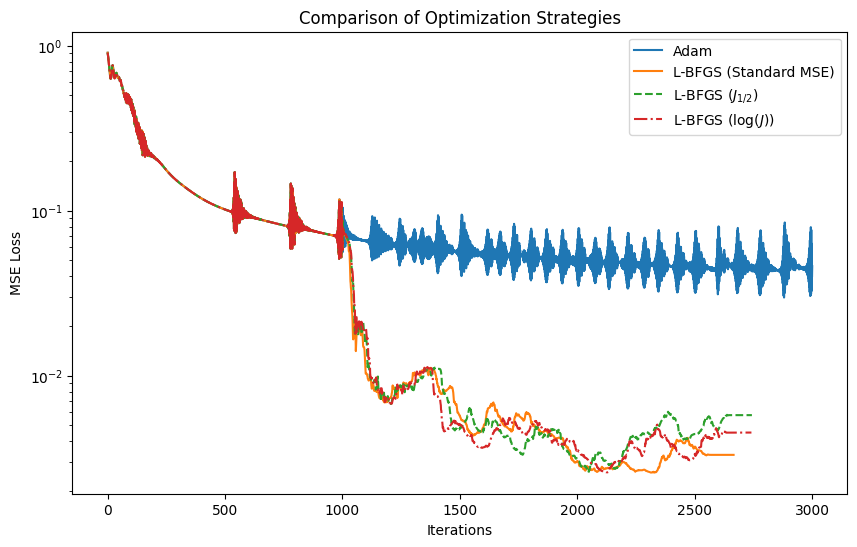

In [157]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.semilogy(l2_relative_errors['adam'], label='Adam') # Exp 1: More Adam
plt.semilogy(l2_relative_errors['adam'][:1001] + l2_relative_errors['std'], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(l2_relative_errors['adam'][:1001] + l2_relative_errors['sqrt'], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(l2_relative_errors['adam'][:1001] + l2_relative_errors['log'], label=r'L-BFGS ($\log(J)$)', linestyle='-.')

#plt.yscale('log') # Crucial to see the difference
plt.xlabel('Iterations')
plt.ylabel('MSE Loss')
plt.title('Comparison of Optimization Strategies')
plt.legend()
plt.show()

In [158]:
# --- Visualization ---
x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)
X, Y = np.meshgrid(x, y)

# Convert to torch for prediction
X_flat = torch.tensor(X.flatten(), dtype=torch.float32).reshape(-1, 1)
Y_flat = torch.tensor(Y.flatten(), dtype=torch.float32).reshape(-1, 1)


with torch.no_grad():
    u_pred_adam = model(X_flat, Y_flat).reshape(100, 100).numpy()
    u_exact = (torch.exp(X_flat)*torch.sin(Y_flat)).reshape(100, 100).numpy()

    u_pred_std = model_std_lbfgs(X_flat, Y_flat).reshape(100, 100).numpy()
    u_pred_sqrt = model_sqrt_lbfgs(X_flat, Y_flat).reshape(100, 100).numpy()
    u_pred_log = model_log_lbfgs(X_flat, Y_flat).reshape(100, 100).numpy()

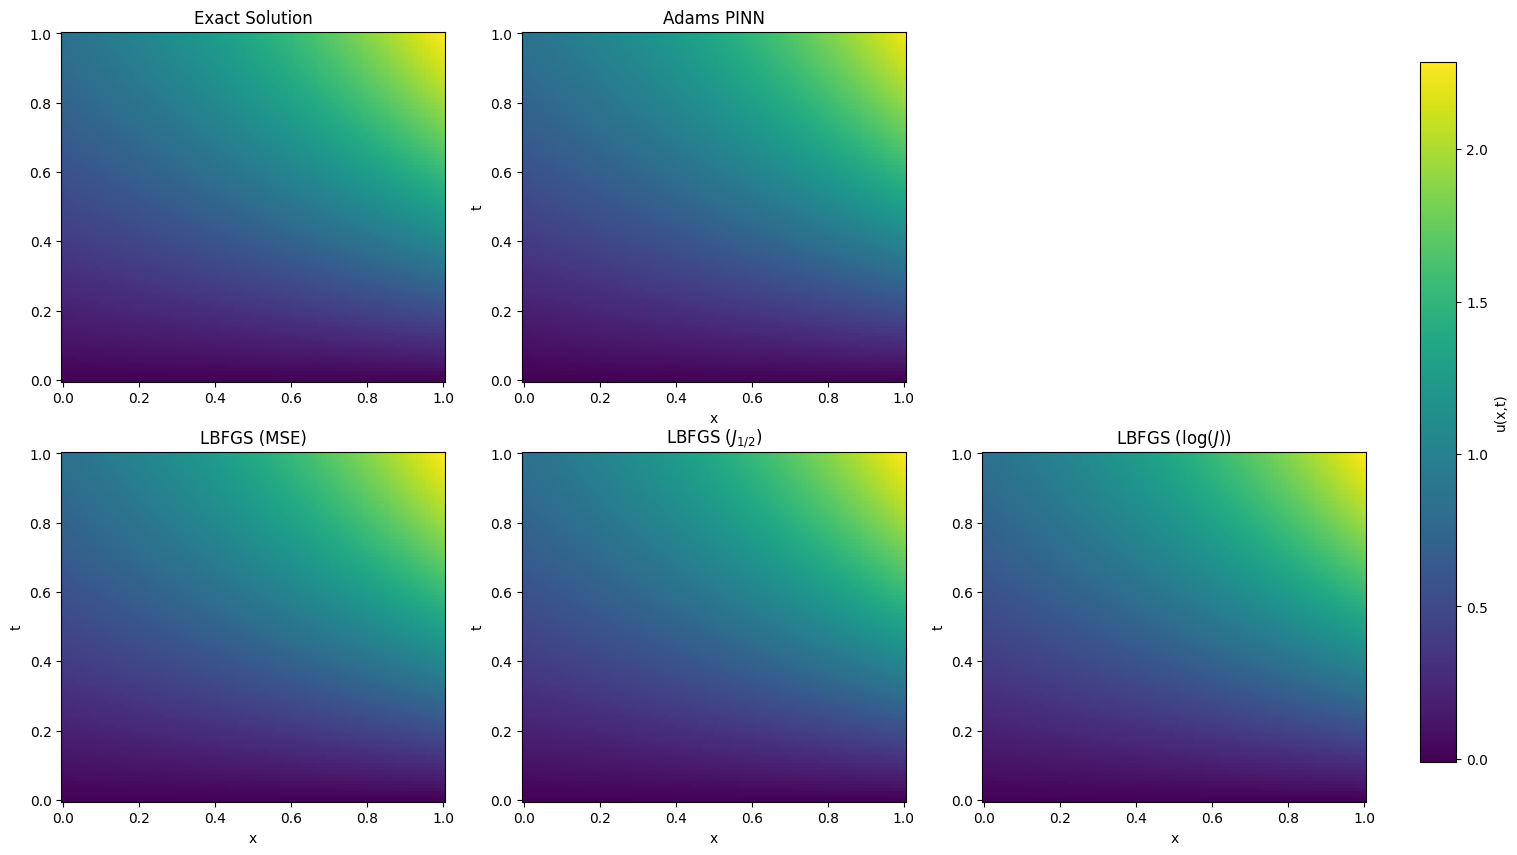

In [159]:
all_data = [u_exact, u_pred_adam, u_pred_std, u_pred_sqrt, u_pred_log]
vmin = min(d.min() for d in all_data)
vmax = max(d.max() for d in all_data)

fig = plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
im = plt.pcolormesh(X, Y, u_exact, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Exact Solution')


plt.subplot(2, 3, 2)
plt.pcolormesh(X, Y, u_pred_adam, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Adams PINN')
plt.xlabel('x')
plt.ylabel('t')

plt.subplot(2, 3, 4)
plt.pcolormesh(X, Y, u_pred_std, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('LBFGS (MSE)')
plt.xlabel('x')
plt.ylabel('t')

plt.subplot(2, 3, 5)
plt.pcolormesh(X, Y, u_pred_sqrt, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'LBFGS ($J_{1/2}$)')
plt.xlabel('x')
plt.ylabel('t')

plt.subplot(2, 3, 6)
plt.pcolormesh(X, Y, u_pred_log, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'LBFGS ($\log(J)$)')
plt.xlabel('x')
plt.ylabel('t')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='u(x,t)')

plt.show()

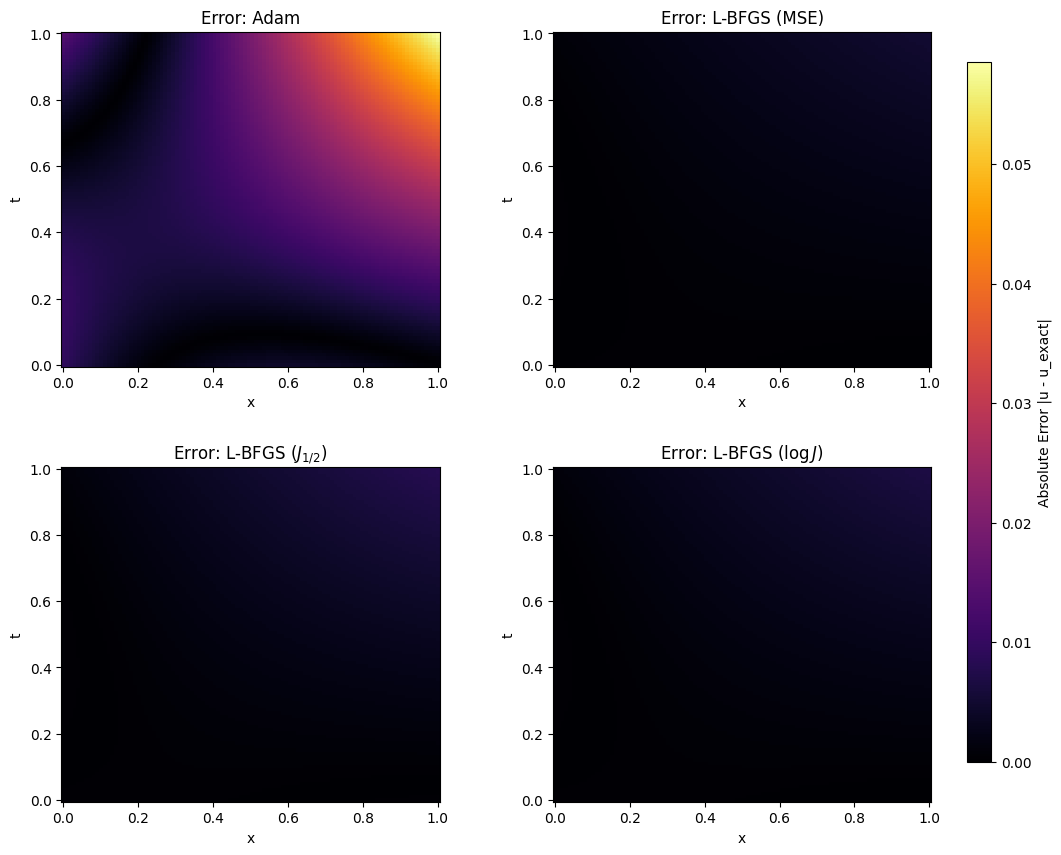

In [160]:
err_adam = abs(u_pred_adam - u_exact)
err_std  = abs(u_pred_std - u_exact)
err_sqrt = abs(u_pred_sqrt - u_exact)
err_log  = abs(u_pred_log - u_exact)

all_errors = [err_adam, err_std, err_sqrt, err_log]
vmin = 0
vmax = max(e.max() for e in all_errors)


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

def plot_error(ax, data, title):
    # We return 'im' to use for the colorbar later
    im = ax.pcolormesh(X, Y, data, shading='auto', cmap='inferno', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    return im


im = plot_error(axes[0, 0], err_adam, "Error: Adam")
plot_error(axes[0, 1], err_std, "Error: L-BFGS (MSE)")
plot_error(axes[1, 0], err_sqrt, r"Error: L-BFGS ($J_{1/2}$)")
plot_error(axes[1, 1], err_log, r"Error: L-BFGS ($\log J$)")

fig.subplots_adjust(right=0.85, hspace=0.3, wspace=0.3)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Absolute Error |u - u_exact|')
plt.show()

In [164]:
print("L_inf error:")
print(f"Adam: {np.max(err_adam):.6e}")
print(f"LBFGS: {np.max(err_std):.6e}")
print(f"LBFGS J_1/2: {np.max(err_sqrt):.6e}")
print(f"LBFGS log(J): {np.max(err_log):.6e}")

L_inf error:
Adam: 5.858088e-02
LBFGS: 5.152464e-03
LBFGS J_1/2: 8.171320e-03
LBFGS log(J): 6.862879e-03


In [161]:
print("L2 error:")
print(f"Adam: {np.linalg.norm(err_adam):.6e}")
print(f"LBFGS: {np.linalg.norm(err_std):.6e}")
print(f"LBFGS J_1/2: {np.linalg.norm(err_sqrt):.6e}")
print(f"LBFGS log(J): {np.linalg.norm(err_log):.6e}")

L2 error:
Adam: 1.684860e+00
LBFGS: 1.753594e-01
LBFGS J_1/2: 2.725858e-01
LBFGS log(J): 2.326699e-01


In [162]:
print("Relative L2 error")
print(f"Adam: {np.linalg.norm(err_adam) / np.linalg.norm(u_exact):.6e}")
print(f"LBFGS: {np.linalg.norm(err_std) / np.linalg.norm(u_exact):.6e}")
print(f"LBFGS J_1/2: {np.linalg.norm(err_sqrt) / np.linalg.norm(u_exact):.6e}")
print(f"LBFGS log(J): {np.linalg.norm(err_log) / np.linalg.norm(u_exact):.6e}")

Relative L2 error
Adam: 1.799693e-02
LBFGS: 1.873111e-03
LBFGS J_1/2: 2.911640e-03
LBFGS log(J): 2.485277e-03


In [163]:
mse_adam = np.mean(err_adam ** 2)
mse_std = np.mean(err_std ** 2)
mse_sqrt = np.mean(err_sqrt ** 2)
mse_log = np.mean(err_log ** 2)

print("MSE:")
print(f"Adam: {mse_adam:.6e}")
print(f"LBFGS: {mse_std:.6e}")
print(f"LBFGS J_1/2: {mse_sqrt:.6e}")
print(f"LBFGS log(J): {mse_log:.6e}")

MSE:
Adam: 2.838755e-04
LBFGS: 3.075091e-06
LBFGS J_1/2: 7.430300e-06
LBFGS log(J): 5.413530e-06
